## 20250928 Ar 273K and 313K merge final dataset

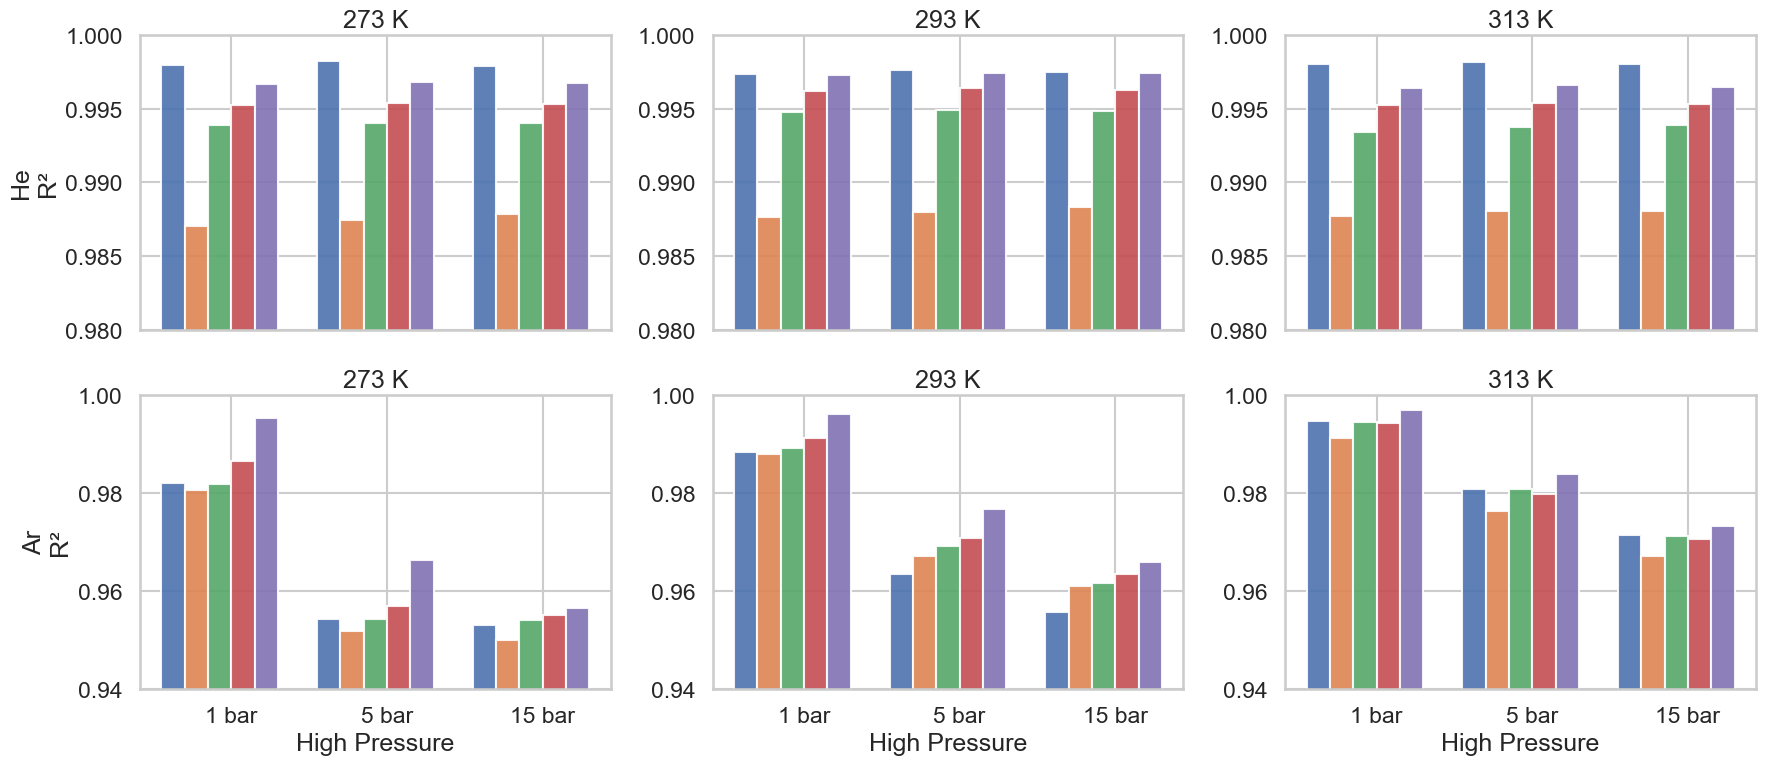

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", context="talk")

df = pd.read_csv("../try14_Ar273_and_313_re_LOWsensitivity/METRICS_OUTPUT_pivot.csv")
# df = pd.read_csv("../Try13/METRICS_OUTPUT_pivot.csv")

df1 = df[(df["MODEL"]=="cat") & (df["SAMPLING"].str.contains("qt_then_rd"))].copy()
df1 
df = pd.read_csv("../Try13/METRICS_OUTPUT_pivot.csv")
df2 = df[df["MODEL"]=="cat"].copy()
df2 = df2[df2["SAMPLING"].str.contains("qt_then_rd")].copy()
df2_AR = df2[df2["GAS"] == "Ar"].copy()
df2_NOTAR = df2[df2["GAS"] != "Ar"].copy()
df2_AR_293 = df2_AR[df2_AR["TEMP"] == 293].copy()
df2 = pd.concat([df2_NOTAR, df2_AR_293], ignore_index=True)
df2
df = pd.concat([df1, df2], ignore_index=True)
gases = ["He","Ar"]
temps = [273,293,313]
lows = ["Henry","0.01","0.05","0.1","0.5"]
highs = ["R2_MEAN_HIGH_1","R2_MEAN_HIGH_5","R2_MEAN_HIGH_15"]

fig, axes = plt.subplots(len(gases), len(temps), figsize=(18,8), sharey=False, sharex=True)

for i, gas in enumerate(gases):
    for j, temp in enumerate(temps):
        ax = axes[i,j] if len(gases)>1 else axes[j]
        subset = df[(df["GAS"]==gas) & (df["TEMP"]==temp)]
        if subset.empty:
            continue

        xpos = np.arange(len(highs))  # 1, 5, 15 bar
        width = 0.15
        all_vals = []  # 🔑 y축 범위 계산용 값 저장

        for k, low in enumerate(lows):
            sublow = subset[subset["LOW"]==low]
            if sublow.empty:
                continue
            vals = [sublow[h].mean() for h in highs]
            all_vals.extend(vals)
            ax.bar(xpos + k*width, vals, width, label=low, alpha=0.9)

        ax.set_xticks(xpos + width*len(lows)/2)
        ax.set_xticklabels([h.replace("R2_MEAN_HIGH_","")+" bar" for h in highs])
        # 🔑 자동 ylim 설정 (값 범위 기반 확대)
        if gas == "He":
            if all_vals:
                vmin, vmax = min(all_vals), max(all_vals)
                margin = (vmax - vmin) * 0.2 if vmax > vmin else 0.01  # 여백
                ax.set_ylim(0.98, 1)  # 기본 ylim 설정
                # ax.set_ylim(vmin - margin, vmax + margin)
        if gas == "Ar":
            if all_vals:
                vmin, vmax = min(all_vals), max(all_vals)
                margin = (vmax - vmin) * 0.2 if vmax > vmin else 0.01  # 여백
                ax.set_ylim(0.94, 1)  # 기본 ylim 설정
                # ax.set_ylim(vmin - margin, vmax + margin)

        if i==len(gases)-1: ax.set_xlabel("High Pressure")
        if j==0: ax.set_ylabel(f"{gas}\nR²")
        ax.set_title(f"{temp} K")

# 범례는 figure 전체에서 한 번만
handles, labels = axes[0,0].get_legend_handles_labels()
# fig.legend(handles, labels, loc="upper right")

plt.tight_layout()
plt.show()


In [ ]:
df2

In [28]:
df2

,GAS,TEMP,MODEL,SAMPLING,LOW,R2_MEAN_HIGH_1,R2_MEAN_HIGH_5,R2_MEAN_HIGH_15,R2_STD_HIGH_1,R2_STD_HIGH_5,...,MAE_STD_HIGH_15,MAPE_MEAN_HIGH_1,MAPE_MEAN_HIGH_5,MAPE_MEAN_HIGH_15,MAPE_STD_HIGH_1,MAPE_STD_HIGH_5,MAPE_STD_HIGH_15,INPUT_HIGH_1,INPUT_HIGH_5,INPUT_HIGH_15
0,H2,293,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.01,NaN,0.979707,NaN,NaN,0.000686,...,NaN,NaN,4.062944,NaN,NaN,0.084687,NaN,NaN,struct+input,NaN
1,He,273,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.01,0.987055,0.987414,0.987830,0.001276,0.001386,...,0.000413,6.768918,6.672528,6.588065,0.152652,0.156586,0.157893,struct+input,struct+input,struct+input
2,He,273,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.05,0.993903,0.994066,0.994008,0.000515,0.000550,...,0.000195,4.410547,4.300519,4.259338,0.084225,0.065846,0.066133,struct+input,struct+input,struct+input
3,He,273,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.1,0.995251,0.995399,0.995328,0.000381,0.000266,...,0.000181,3.837934,3.733794,3.713334,0.056787,0.056560,0.079069,struct+input,struct+input,struct+input
4,He,273,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.5,0.996660,0.996843,0.996747,0.000391,0.000305,...,0.000092,3.164496,3.016463,2.977967,0.129256,0.093890,0.087682,struct+input,struct+input,struct+input
5,He,273,cat,qt_then_rd__cat_TRAIN_RATIO0.8,Henry,0.998010,0.998231,0.997888,0.000246,0.000202,...,0.000200,2.357821,2.246318,2.283853,0.081423,0.097547,0.084433,struct+input,struct+input,struct+input
6,He,293,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.01,0.987630,0.988015,0.988320,0.001321,0.001008,...,0.000267,7.060761,6.997915,6.931449,0.171500,0.160961,0.149331,struct+input,struct+input,struct+input
7,He,293,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.05,0.994794,0.994905,0.994839,0.000356,0.000362,...,0.000172,4.223854,4.200231,4.161024,0.092735,0.084019,0.111820,struct+input,struct+input,struct+input
8,He,293,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.1,0.996225,0.996429,0.996298,0.000123,0.000149,...,0.000094,3.565711,3.445021,3.473909,0.044046,0.088944,0.095493,struct+input,struct+input,struct+input
9,He,293,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.5,0.997334,0.997467,0.997411,0.000678,0.000728,...,0.000122,2.738556,2.646463,2.651335,0.071916,0.037138,0.073064,struct+input,struct+input,struct+input


In [29]:
df1

,GAS,TEMP,MODEL,SAMPLING,LOW,R2_MEAN_HIGH_1,R2_MEAN_HIGH_5,R2_MEAN_HIGH_15,R2_STD_HIGH_1,R2_STD_HIGH_5,R2_STD_HIGH_15,MAE_MEAN_HIGH_1,MAE_MEAN_HIGH_5,MAE_MEAN_HIGH_15,MAE_STD_HIGH_1,MAE_STD_HIGH_5,MAE_STD_HIGH_15,INPUT_HIGH_1,INPUT_HIGH_5,INPUT_HIGH_15
0,Ar,273,cat,qt_then_rd_,0.01,0.980530,0.951826,0.950030,0.001539,0.002291,0.003122,0.019842,0.111568,0.249314,0.000491,0.002174,0.001239,struct+input,struct+input,struct+input
1,Ar,273,cat,qt_then_rd_,0.05,0.981844,0.954335,0.954147,0.000772,0.002125,0.001984,0.017917,0.109176,0.247901,0.000514,0.002530,0.005247,struct+input,struct+input,struct+input
2,Ar,273,cat,qt_then_rd_,0.1,0.986484,0.956930,0.955170,0.002860,0.003044,0.003474,0.016646,0.106333,0.244007,0.000469,0.002683,0.004047,struct+input,struct+input,struct+input
3,Ar,273,cat,qt_then_rd_,0.5,0.995193,0.966313,0.956570,0.000412,0.003117,0.002718,0.011534,0.096432,0.236177,0.000187,0.002029,0.005845,struct+input,struct+input,struct+input
4,Ar,273,cat,qt_then_rd_,Henry,0.981980,0.954250,0.953123,0.003867,0.001846,0.004056,0.018495,0.109174,0.248908,0.000707,0.002559,0.004940,struct+input,struct+input,struct+input
5,Ar,313,cat,qt_then_rd_,0.01,0.991150,0.976268,0.967135,0.000547,0.001180,0.002416,0.007433,0.043513,0.126947,0.000130,0.000856,0.003363,struct+input,struct+input,struct+input
6,Ar,313,cat,qt_then_rd_,0.05,0.994393,0.980706,0.971218,0.000567,0.002003,0.000622,0.005624,0.037976,0.116705,0.000069,0.001216,0.001690,struct+input,struct+input,struct+input
7,Ar,313,cat,qt_then_rd_,0.1,0.994223,0.979745,0.970678,0.000757,0.000579,0.001578,0.005197,0.037391,0.116315,0.000085,0.000277,0.001866,struct+input,struct+input,struct+input
8,Ar,313,cat,qt_then_rd_,0.5,0.996939,0.983854,0.973323,0.000158,0.001485,0.001962,0.004210,0.033565,0.109868,0.000111,0.000615,0.001572,struct+input,struct+input,struct+input
9,Ar,313,cat,qt_then_rd_,Henry,0.994573,0.980866,0.971372,0.000746,0.000803,0.000634,0.005072,0.036789,0.114924,0.000162,0.000478,0.000578,struct+input,struct+input,struct+input


In [17]:
df[(df["GAS"]=="Ar") & (df["TEMP"]==293)]

,GAS,TEMP,MODEL,SAMPLING,LOW,R2_MEAN_HIGH_1,R2_MEAN_HIGH_5,R2_MEAN_HIGH_15,R2_STD_HIGH_1,R2_STD_HIGH_5,...,MAE_STD_HIGH_15,INPUT_HIGH_1,INPUT_HIGH_5,INPUT_HIGH_15,MAPE_MEAN_HIGH_1,MAPE_MEAN_HIGH_5,MAPE_MEAN_HIGH_15,MAPE_STD_HIGH_1,MAPE_STD_HIGH_5,MAPE_STD_HIGH_15
10,Ar,293,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.01,0.987939,0.967201,0.961106,0.000889,0.001146,...,0.001825,struct+input,struct+input,struct+input,3.163945,4.592780,5.698899,0.065706,0.046825,0.076660
11,Ar,293,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.05,0.989225,0.969082,0.961640,0.002016,0.001683,...,0.004391,struct+input,struct+input,struct+input,2.632042,4.262427,5.578408,0.087063,0.096453,0.193965
12,Ar,293,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.1,0.991211,0.970808,0.963529,0.000325,0.001885,...,0.002416,struct+input,struct+input,struct+input,2.534771,4.207946,5.577385,0.056771,0.049712,0.074902
13,Ar,293,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.5,0.996107,0.976678,0.965971,0.000231,0.001637,...,0.004052,struct+input,struct+input,struct+input,1.833201,3.736026,5.254246,0.033167,0.043637,0.126238
14,Ar,293,cat,qt_then_rd__cat_TRAIN_RATIO0.8,Henry,0.988409,0.963425,0.955755,0.002452,0.003571,...,0.003684,struct+input,struct+input,struct+input,2.501384,4.268114,5.609694,0.058238,0.152032,0.126376
15,Ar,293,cat,random_struct__cat_TRAIN_RATIO0.8,0.01,0.327332,0.477390,0.704812,0.046794,0.024377,...,0.010570,struct,struct,struct,51.870022,33.199821,21.846410,3.214338,0.973412,0.468541
16,Ar,293,cat,random_struct__cat_TRAIN_RATIO0.8,0.05,0.327332,0.477390,0.704812,0.046794,0.024377,...,0.010570,struct,struct,struct,51.870022,33.199821,21.846410,3.214338,0.973412,0.468541
17,Ar,293,cat,random_struct__cat_TRAIN_RATIO0.8,0.1,0.327332,0.477390,0.704812,0.046794,0.024377,...,0.010570,struct,struct,struct,51.870022,33.199821,21.846410,3.214338,0.973412,0.468541
18,Ar,293,cat,random_struct__cat_TRAIN_RATIO0.8,0.5,0.327332,0.477390,0.704812,0.046794,0.024377,...,0.010570,struct,struct,struct,51.870022,33.199821,21.846410,3.214338,0.973412,0.468541
19,Ar,293,cat,random_struct__cat_TRAIN_RATIO0.8,Henry,0.367182,0.512002,0.716389,0.040087,0.010112,...,0.011802,struct,struct,struct,52.244491,33.491558,22.010992,3.710508,1.159552,0.685482


## 이전 버전 METRIC사용 (Ar 273K, 313K이 일관되지 않은 MOF Database기반)

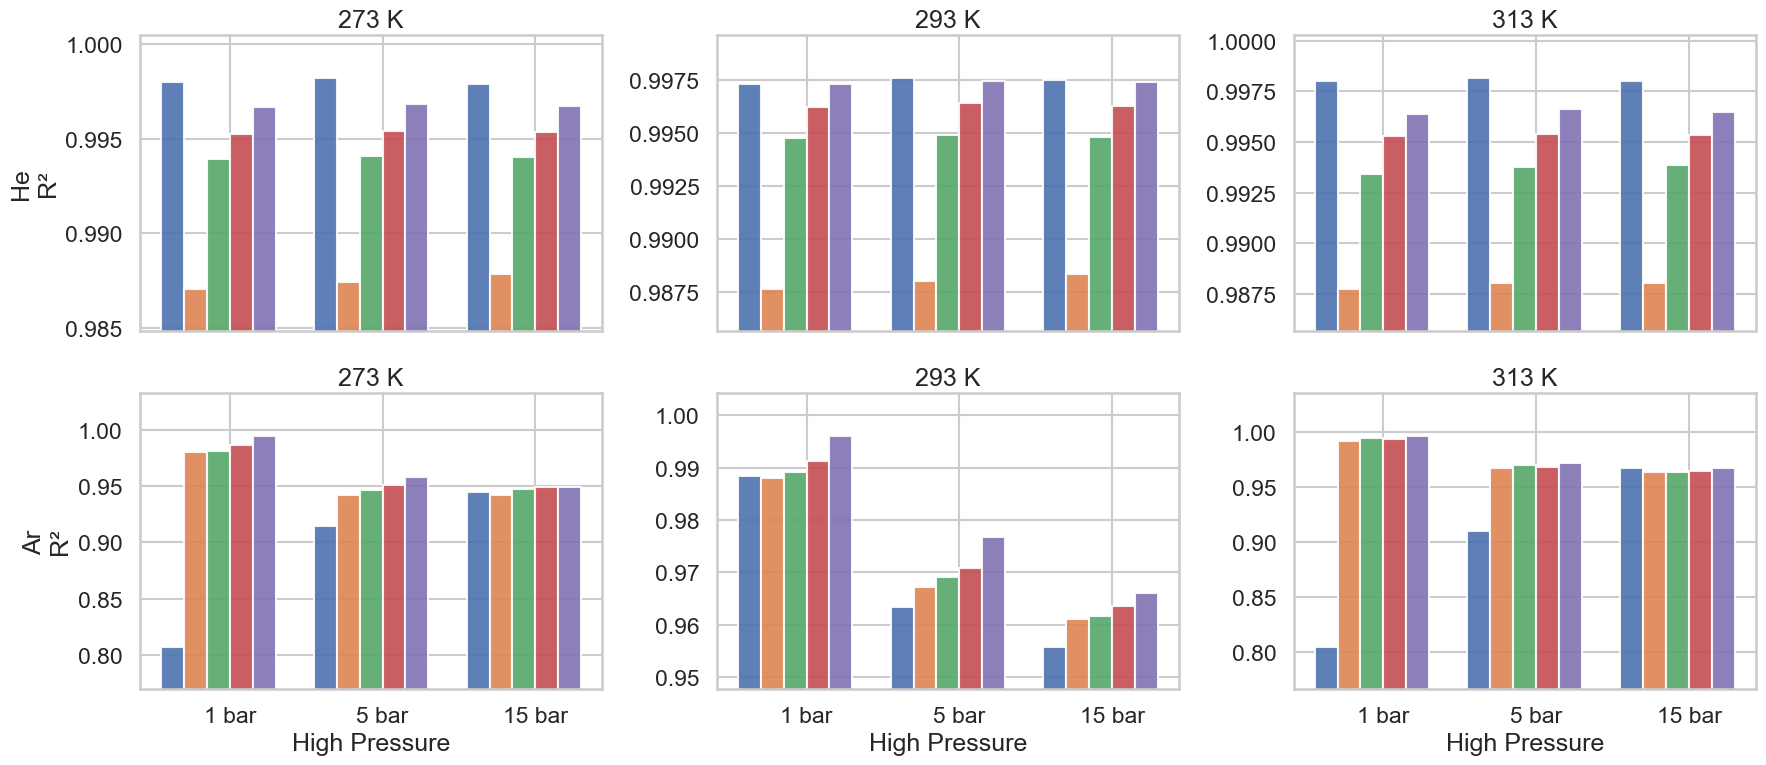

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", context="talk")

df = pd.read_csv("../Try13/METRICS_OUTPUT_pivot.csv")
df = df[(df["MODEL"]=="cat") & (df["SAMPLING"].str.contains("qt_then_rd"))].copy()

gases = ["He","Ar"]
temps = [273,293,313]
lows = ["Henry","0.01","0.05","0.1","0.5"]
highs = ["R2_MEAN_HIGH_1","R2_MEAN_HIGH_5","R2_MEAN_HIGH_15"]

fig, axes = plt.subplots(len(gases), len(temps), figsize=(18,8), sharey=False, sharex=True)

for i, gas in enumerate(gases):
    for j, temp in enumerate(temps):
        ax = axes[i,j] if len(gases)>1 else axes[j]
        subset = df[(df["GAS"]==gas) & (df["TEMP"]==temp)]
        if subset.empty:
            continue

        xpos = np.arange(len(highs))  # 1, 5, 15 bar
        width = 0.15
        all_vals = []  # 🔑 y축 범위 계산용 값 저장

        for k, low in enumerate(lows):
            sublow = subset[subset["LOW"]==low]
            if sublow.empty:
                continue
            vals = [sublow[h].mean() for h in highs]
            all_vals.extend(vals)
            ax.bar(xpos + k*width, vals, width, label=low, alpha=0.9)

        ax.set_xticks(xpos + width*len(lows)/2)
        ax.set_xticklabels([h.replace("R2_MEAN_HIGH_","")+" bar" for h in highs])

        # 🔑 자동 ylim 설정 (값 범위 기반 확대)
        if all_vals:
            vmin, vmax = min(all_vals), max(all_vals)
            margin = (vmax - vmin) * 0.2 if vmax > vmin else 0.01  # 여백
            ax.set_ylim(vmin - margin, vmax + margin)

        if i==len(gases)-1: ax.set_xlabel("High Pressure")
        if j==0: ax.set_ylabel(f"{gas}\nR²")
        ax.set_title(f"{temp} K")

# 범례는 figure 전체에서 한 번만
handles, labels = axes[0,0].get_legend_handles_labels()
# fig.legend(handles, labels, loc="upper right")

plt.tight_layout()
plt.show()


In [17]:
vals

[0.9563451100414408, 0.9575112898410245, 0.965450295908273]

In [4]:
df.columns

Index(['GAS', 'TEMP', 'MODEL', 'SAMPLING', 'LOW', 'R2_MEAN_HIGH_1',
       'R2_MEAN_HIGH_5', 'R2_MEAN_HIGH_15', 'R2_STD_HIGH_1', 'R2_STD_HIGH_5',
       'R2_STD_HIGH_15', 'MAE_MEAN_HIGH_1', 'MAE_MEAN_HIGH_5',
       'MAE_MEAN_HIGH_15', 'MAE_STD_HIGH_1', 'MAE_STD_HIGH_5',
       'MAE_STD_HIGH_15', 'MAPE_MEAN_HIGH_1', 'MAPE_MEAN_HIGH_5',
       'MAPE_MEAN_HIGH_15', 'MAPE_STD_HIGH_1', 'MAPE_STD_HIGH_5',
       'MAPE_STD_HIGH_15', 'INPUT_HIGH_1', 'INPUT_HIGH_5', 'INPUT_HIGH_15'],
      dtype='object')

In [3]:
df

,GAS,TEMP,MODEL,SAMPLING,LOW,R2_MEAN_HIGH_1,R2_MEAN_HIGH_5,R2_MEAN_HIGH_15,R2_STD_HIGH_1,R2_STD_HIGH_5,...,MAE_STD_HIGH_15,MAPE_MEAN_HIGH_1,MAPE_MEAN_HIGH_5,MAPE_MEAN_HIGH_15,MAPE_STD_HIGH_1,MAPE_STD_HIGH_5,MAPE_STD_HIGH_15,INPUT_HIGH_1,INPUT_HIGH_5,INPUT_HIGH_15
0,Ar,273,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.01,0.980530,0.942551,0.942233,0.001539,0.002202,...,0.002964,3.604884,6.017872,6.906274,0.097235,0.173088,0.122752,struct+input,struct+input,struct+input
1,Ar,273,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.05,0.981844,0.946434,0.947935,0.000772,0.002550,...,0.005185,3.149899,5.811729,6.757988,0.097062,0.173467,0.146044,struct+input,struct+input,struct+input
2,Ar,273,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.10,0.986484,0.950708,0.948975,0.002860,0.002741,...,0.006056,2.959337,5.561020,6.672832,0.063514,0.145041,0.154566,struct+input,struct+input,struct+input
3,Ar,273,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.50,0.995210,0.958574,0.949225,0.000432,0.003612,...,0.006417,2.088218,5.123617,6.539972,0.029519,0.090167,0.121571,struct+input,struct+input,struct+input
36,Ar,293,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.01,0.987939,0.967201,0.961106,0.000889,0.001146,...,0.001825,3.163945,4.592780,5.698899,0.065706,0.046825,0.076660,struct+input,struct+input,struct+input
37,Ar,293,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.05,0.989225,0.969082,0.961640,0.002016,0.001683,...,0.004391,2.632042,4.262427,5.578408,0.087063,0.096453,0.193965,struct+input,struct+input,struct+input
38,Ar,293,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.10,0.991211,0.970808,0.963529,0.000325,0.001885,...,0.002416,2.534771,4.207946,5.577385,0.056771,0.049712,0.074902,struct+input,struct+input,struct+input
39,Ar,293,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.50,0.996107,0.976678,0.965971,0.000231,0.001637,...,0.004052,1.833201,3.736026,5.254246,0.033167,0.043637,0.126238,struct+input,struct+input,struct+input
72,Ar,313,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.01,0.991559,0.967340,0.963651,0.000244,0.004825,...,0.001245,2.904731,4.379958,5.360455,0.071018,0.134309,0.096533,struct+input,struct+input,struct+input
73,Ar,313,cat,qt_then_rd__cat_TRAIN_RATIO0.8,0.05,0.994393,0.969743,0.964138,0.000567,0.001802,...,0.002204,2.248791,4.067569,5.278337,0.024586,0.122536,0.071897,struct+input,struct+input,struct+input
